# weak supervision

In [1]:
import pandas as pd
import re

df = pd.read_csv("comments_ready_backup.csv")
df["text_clean"] = df["text_clean"].fillna("")

positive_keywords = ["tuyệt vời","đẹp","mê","thích","ok","good","đỉnh","yêu"]
negative_keywords = ["tệ","chán","xấu","dở","lỗi","giận","bực","ghét"]

def weak_label(text):
    text = text.lower()
    if any(w in text for w in positive_keywords): return "positive"
    if any(w in text for w in negative_keywords): return "negative"
    if re.search(r"[❤️😍👍🤩😆😀😄😁😊😋😎]", text): return "positive"
    if re.search(r"[💔😡🤬😞😢😭😠👎]", text): return "negative"
    return "neutral"

df["weak_label"] = df["text_clean"].apply(weak_label)
df["weak_label"].value_counts()
df.to_csv("comments_weaklabel.csv", index=False, encoding="utf-8-sig")
print("✅ Saved comments_weaklabel.csv with proper UTF-8-SIG encoding")

✅ Saved comments_weaklabel.csv with proper UTF-8-SIG encoding


d:\DACN - HQM\DACN_KHDL\MyCode\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔹 Generating E5 embeddings with intfloat/multilingual-e5-large ...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Batches: 100%|██████████| 11672/11672 [2:06:59<00:00,  1.53it/s] 


✅ Embeddings saved to: embeddings_e5.npy
Embedding shape: (186744, 1024)

---- LOGISTIC REGRESSION ----
              precision    recall  f1-score   support

    negative       0.78      0.45      0.57      1714
     neutral       0.92      0.98      0.95     30805
    positive       0.79      0.59      0.68      4830

    accuracy                           0.90     37349
   macro avg       0.83      0.67      0.73     37349
weighted avg       0.90      0.90      0.89     37349


---- LINEAR SVM ----
              precision    recall  f1-score   support

    negative       0.84      0.51      0.64      1714
     neutral       0.93      0.98      0.95     30805
    positive       0.82      0.63      0.71      4830

    accuracy                           0.91     37349
   macro avg       0.86      0.71      0.77     37349
weighted avg       0.91      0.91      0.91     37349



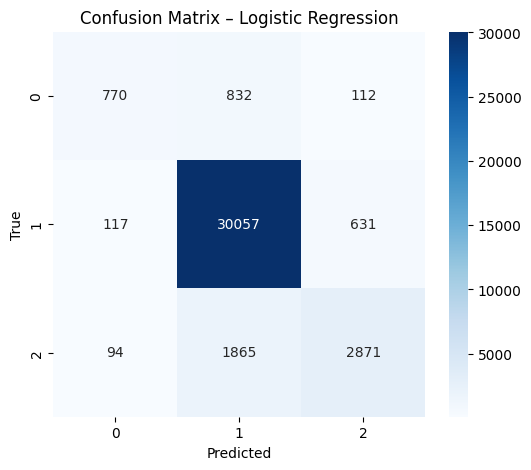

In [1]:
# =========================================================
# STEP 2B – SENTENCE EMBEDDING + SENTIMENT BASELINE
# Using: intfloat/multilingual-e5-large
# =========================================================

from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns, os

# -------- CONFIG --------
MODEL_NAME = "intfloat/multilingual-e5-large"     
IN_FILE = "comments_weaklabel.csv"
EMB_FILE = "embeddings_e5.npy"
TEST_SIZE = 0.2
RANDOM_STATE = 42

# -------- LOAD DATA --------
df = pd.read_csv(IN_FILE, encoding="utf-8-sig")
texts_raw = df["text_clean"].fillna("").astype(str).tolist()

# E5 cần thêm prefix "passage:"
texts = [f"passage: {t}" for t in texts_raw]

labels = df["weak_label"].astype(str)

# -------- LOAD MODEL + EMBEDDING --------
if os.path.exists(EMB_FILE):
    print(f"✅ Found local embeddings: {EMB_FILE}")
    X = np.load(EMB_FILE)
else:
    print(f"🔹 Generating E5 embeddings with {MODEL_NAME} ...")
    model = SentenceTransformer(MODEL_NAME)
    
    X = model.encode(
        texts,
        batch_size=16,              
        normalize_embeddings=True,
        show_progress_bar=True
    )
    
    np.save(EMB_FILE, X)
    print(f"✅ Embeddings saved to: {EMB_FILE}")

print(f"Embedding shape: {X.shape}")

# -------- TRAIN / TEST SPLIT --------
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels
)

# -------- BASELINE: LOGISTIC REGRESSION --------
logreg = LogisticRegression(max_iter=2000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print("\n---- LOGISTIC REGRESSION ----")
print(classification_report(y_test, y_pred_lr))

# -------- BASELINE: LINEAR SVM --------
svm = LinearSVC()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

print("\n---- LINEAR SVM ----")
print(classification_report(y_test, y_pred_svm))

# -------- CONFUSION MATRIX --------
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()